In [1]:
import pandas as pd

df_qol = pd.read_csv('data/quality_of_life_indices_by_country.csv')


In [2]:
df_qol['Year'] = df_qol['Year'].astype(str).str.replace(r'/2$', '', regex=True)
df_qol = df_qol.groupby(['Country', 'Year'], as_index=False, sort=False).mean(numeric_only=True)

In [3]:
df_qol

,Country,Year,Rank,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index,Climate Index
0,Switzerland,2014,1.0,207.35,137.55,70.00,68.00,143.20,7.05,25.15,26.40,NaN
1,Germany,2014,2.0,189.65,109.05,71.90,76.00,86.95,5.85,33.75,30.25,NaN
2,Sweden,2014,3.5,178.75,104.00,59.85,76.15,101.10,9.55,33.25,17.35,NaN
3,Finland,2014,3.5,180.75,97.25,70.80,68.85,102.65,7.50,34.25,16.35,NaN
4,Denmark,2014,5.0,172.10,96.15,71.80,84.10,115.00,6.15,26.90,36.20,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
442,Serbia,2026,33.0,127.60,64.70,63.00,52.10,42.60,14.80,30.60,65.80,82.7
443,North Macedonia,2026,34.0,124.20,66.10,58.60,55.40,35.50,11.80,24.30,79.20,79.9
444,Ukraine,2026,35.0,117.10,51.10,53.10,55.80,28.20,12.80,37.80,62.20,71.3
445,Russia,2026,36.0,115.60,63.20,61.80,61.60,36.50,13.70,43.30,58.40,38.0


In [4]:
df_wdi = pd.read_excel('data/wdi.xlsx')

In [5]:
df_wdi.drop(range(148,153), inplace=True)

In [6]:
df_wdi = df_wdi.drop(columns=['Indicator Code'])

In [7]:
print(df_wdi.columns.tolist())

['Country Name', 'Country Code', 'Indicator Name', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


In [8]:
df_wdi1 = pd.DataFrame({"Country Name": [], "Country Code": [],"Year":[], "School enrollment, primary (%gross)": [], "Individuals using the internet (% of population)": [], "GDP per capita, PPP (current international $)": []})

In [9]:
import country_converter as cc

In [10]:
df_qol['Country Code'] = cc.convert(names=df_qol['Country'], to='ISO3')

In [11]:
df_qol["Year"] = df_qol["Year"].astype(int)

In [12]:
df_whr = pd.read_excel('data/WHR26_Data_Figure_2.1.xlsx')

In [13]:
df_whr.head()

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


In [14]:
df_whr['Country Code'] = cc.convert(names=df_whr['Country name'], to='ISO3')

In [15]:
df_whr = df_whr[df_whr['Country Code'].isin(df_qol['Country Code'])]

In [16]:
atributi = [
    "Year",
    "Country Code",
    'Country name', 
    'Life evaluation (3-year average)', 
    'Explained by: Log GDP per capita', 
    'Explained by: Social support', 
    'Explained by: Healthy life expectancy', 
    'Explained by: Freedom to make life choices', 
    'Explained by: Generosity', 
    'Explained by: Perceptions of corruption',
    'Dystopia + residual'
]

skupno = pd.merge(df_qol, df_whr[atributi], on=["Year", "Country Code"], how="inner")

In [17]:
skupno.info()

<class 'pandas.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 22 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country                                     406 non-null    str    
 1   Year                                        406 non-null    int64  
 2   Rank                                        406 non-null    float64
 3   Quality of Life Index                       406 non-null    float64
 4   Purchasing Power Index                      406 non-null    float64
 5   Safety Index                                406 non-null    float64
 6   Health Care Index                           406 non-null    float64
 7   Cost of Living Index                        406 non-null    float64
 8   Property Price to Income Ratio              406 non-null    float64
 9   Traffic Commute Time Index                  406 non-null    float64
 10  Pollution Index          

In [18]:
skupno.drop(columns=['Country name'], inplace=True)

In [19]:
skupno = skupno[['Country', 'Country Code', 'Year', 'Rank', 'Quality of Life Index',
       'Purchasing Power Index', 'Safety Index', 'Health Care Index',
       'Cost of Living Index', 'Property Price to Income Ratio',
       'Traffic Commute Time Index', 'Pollution Index', 'Climate Index',
       'Life evaluation (3-year average)',
       'Explained by: Log GDP per capita', 'Explained by: Social support',
       'Explained by: Healthy life expectancy',
       'Explained by: Freedom to make life choices',
       'Explained by: Generosity', 'Explained by: Perceptions of corruption',
       'Dystopia + residual']]

In [20]:
skupno.head()

,Country,Country Code,Year,Rank,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,...,Pollution Index,Climate Index,Life evaluation (3-year average),Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Switzerland,CHE,2014,1.0,207.35,137.55,70.00,68.00,143.20,7.05,...,26.40,NaN,7.587,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Germany,DEU,2014,2.0,189.65,109.05,71.90,76.00,86.95,5.85,...,30.25,NaN,6.750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sweden,SWE,2014,3.5,178.75,104.00,59.85,76.15,101.10,9.55,...,17.35,NaN,7.364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Finland,FIN,2014,3.5,180.75,97.25,70.80,68.85,102.65,7.50,...,16.35,NaN,7.406,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Denmark,DNK,2014,5.0,172.10,96.15,71.80,84.10,115.00,6.15,...,36.20,NaN,7.527,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
df_hdi = pd.read_csv('data/HDR25_Composite_indices_complete_time_series.csv', encoding='Windows-1250')

In [22]:
df_hdi = df_hdi[df_hdi['iso3'].isin(df_qol['Country Code'])]

In [23]:
df_hdi.drop(columns=['country', 'region'], inplace=True)

In [24]:
df_hdi.head()

,iso3,hdicode,hdi_rank_2023,hdi_1990,hdi_1991,hdi_1992,hdi_1993,hdi_1994,hdi_1995,hdi_1996,...,pop_total_2014,pop_total_2015,pop_total_2016,pop_total_2017,pop_total_2018,pop_total_2019,pop_total_2020,pop_total_2021,pop_total_2022,pop_total_2023
1,ALB,Very High,71.0,0.654,0.638,0.622,0.624,0.629,0.638,0.647,...,2.903749,2.898632,2.897867,2.898242,2.894231,2.885009,2.871954,2.849636,2.827608,2.811655
9,AUT,Very High,22.0,0.832,0.835,0.841,0.845,0.851,0.856,0.861,...,8.547818,8.644039,8.737915,8.798777,8.841651,8.880876,8.921405,8.967056,9.064677,9.130429
15,BLR,Very High,65.0,NaN,NaN,NaN,NaN,NaN,0.692,0.697,...,9.472708,9.487293,9.499064,9.495790,9.480031,9.435420,9.350944,9.251365,9.173237,9.115680
16,BEL,Very High,10.0,0.824,0.829,0.845,0.860,0.868,0.875,0.881,...,11.210119,11.275334,11.332700,11.376580,11.428605,11.490618,11.540107,11.570844,11.641820,11.712893
21,BIH,Very High,74.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.564829,3.518540,3.473003,3.428682,3.387000,3.345533,3.299349,3.244908,3.204802,3.185073


In [25]:
df_hdi = df_hdi.loc[:, ~df_hdi.columns.str.contains(r'^\d{4}$') | df_hdi.columns.str.contains(r'(201[4-9]|202[0-5])')]
df_hdi = df_hdi.loc[:, df_hdi.columns.isin(['iso3']) | df_hdi.columns.str.contains(r'(201[4-9]|202[0-5])')]

C:\Users\Kristijan\AppData\Local\Temp\ipykernel_13592\3039077932.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_hdi = df_hdi.loc[:, ~df_hdi.columns.str.contains(r'^\d{4}$') | df_hdi.columns.str.contains(r'(201[4-9]|202[0-5])')]
C:\Users\Kristijan\AppData\Local\Temp\ipykernel_13592\3039077932.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_hdi = df_hdi.loc[:, df_hdi.columns.isin(['iso3']) | df_hdi.columns.str.contains(r'(201[4-9]|202[0-5])')]


In [26]:
df_hdi

,iso3,hdi_rank_2023,hdi_2014,hdi_2015,hdi_2016,hdi_2017,hdi_2018,hdi_2019,hdi_2020,hdi_2021,...,pop_total_2014,pop_total_2015,pop_total_2016,pop_total_2017,pop_total_2018,pop_total_2019,pop_total_2020,pop_total_2021,pop_total_2022,pop_total_2023
1,ALB,71.0,0.797,0.797,0.797,0.798,0.801,0.805,0.794,0.794,...,2.903749,2.898632,2.897867,2.898242,2.894231,2.885009,2.871954,2.849636,2.827608,2.811655
9,AUT,22.0,0.919,0.919,0.921,0.922,0.925,0.928,0.925,0.930,...,8.547818,8.644039,8.737915,8.798777,8.841651,8.880876,8.921405,8.967056,9.064677,9.130429
15,BLR,65.0,0.825,0.825,0.825,0.828,0.827,0.826,0.815,0.817,...,9.472708,9.487293,9.499064,9.495790,9.480031,9.435420,9.350944,9.251365,9.173237,9.115680
16,BEL,10.0,0.930,0.933,0.936,0.940,0.942,0.945,0.939,0.948,...,11.210119,11.275334,11.332700,11.376580,11.428605,11.490618,11.540107,11.570844,11.641820,11.712893
21,BIH,74.0,0.765,0.769,0.776,0.780,0.785,0.788,0.783,0.783,...,3.564829,3.518540,3.473003,3.428682,3.387000,3.345533,3.299349,3.244908,3.204802,3.185073
25,BGR,55.0,0.819,0.824,0.827,0.829,0.832,0.835,0.826,0.817,...,7.223450,7.177517,7.127434,7.075635,7.024745,6.975469,6.933652,6.877225,6.825864,6.795803
41,HRV,41.0,0.848,0.852,0.856,0.862,0.867,0.872,0.867,0.876,...,4.219479,4.183728,4.136444,4.079200,4.024868,3.986334,3.953958,3.924610,3.907027,3.896024
44,CZE,29.0,0.898,0.900,0.902,0.904,0.901,0.903,0.898,0.901,...,10.517226,10.524416,10.531948,10.541341,10.548937,10.554875,10.550130,10.530682,10.673213,10.809716
46,DNK,4.0,0.939,0.943,0.951,0.951,0.950,0.953,0.954,0.958,...,5.643794,5.683701,5.728201,5.765168,5.793825,5.814618,5.831530,5.856776,5.902903,5.948137
55,EST,36.0,0.885,0.888,0.890,0.894,0.897,0.901,0.901,0.899,...,1.314452,1.314576,1.315849,1.317424,1.321964,1.326822,1.329670,1.331749,1.350091,1.367196


In [27]:
df_hdi_melted = pd.wide_to_long(df_hdi, stubnames=['hdi','le','eys','mys','gnipc'], i='iso3', j='Year', sep='_')

In [28]:
df_hdi_melted.head()

,,abr_2014,abr_2015,abr_2016,abr_2017,abr_2018,abr_2019,abr_2020,abr_2021,abr_2022,abr_2023,...,se_m_2019,se_m_2020,se_m_2021,se_m_2022,se_m_2023,hdi,le,eys,mys,gnipc
iso3,Year,,,,,,,,,,,,,,,,,,,,,
ALB,2014,21.767,20.656,18.518,16.778,15.456,14.949,14.004,13.002,12.827,12.789,...,92.677055,93.141407,93.605759,93.857521,93.857521,0.797,78.029,15.720370,10.00868,13019.67144
AUT,2014,7.784,7.848,7.505,6.897,5.715,5.290,4.907,4.426,4.205,3.836,...,99.057083,99.205521,99.026894,98.423279,98.683769,0.919,81.390,16.022249,12.01000,62502.99636
BLR,2014,21.116,18.336,16.076,13.395,11.932,11.351,10.911,10.659,9.903,8.595,...,99.029999,99.460558,99.892990,99.892990,99.892990,0.825,73.245,15.413680,11.66500,25819.62880
BEL,2014,7.153,6.659,6.228,5.905,5.528,5.204,4.884,4.609,4.372,3.670,...,89.709999,90.162140,90.726936,90.955208,90.955208,0.930,81.080,19.707769,11.64000,58998.64981
BIH,2014,10.289,10.818,11.300,11.613,11.814,11.354,11.311,11.192,11.089,11.217,...,91.669998,94.019997,95.109997,96.199997,96.199997,0.765,77.089,13.646000,9.19000,13742.35329


In [29]:
df_hdi_melted.reset_index(inplace=True)

C:\Users\Kristijan\AppData\Local\Temp\ipykernel_13592\744710143.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_hdi_melted.reset_index(inplace=True)


In [30]:
df_hdi_melted = df_hdi_melted[['iso3', 'Year','hdi_rank_2023', 'hdi', 'le', 'eys', 'mys', 'gnipc']]

In [31]:
df_hdi_melted.head()

,iso3,Year,hdi_rank_2023,hdi,le,eys,mys,gnipc
0,ALB,2014,71.0,0.797,78.029,15.720370,10.00868,13019.67144
1,AUT,2014,22.0,0.919,81.390,16.022249,12.01000,62502.99636
2,BLR,2014,65.0,0.825,73.245,15.413680,11.66500,25819.62880
3,BEL,2014,10.0,0.930,81.080,19.707769,11.64000,58998.64981
4,BIH,2014,74.0,0.765,77.089,13.646000,9.19000,13742.35329


In [32]:
df_hdi_melted.rename(columns={'iso3': 'Country Code', 'hdi_rank_2023': 'HDI Rank', 'hdi': 'HDI', 'le': 'Life Expectancy', 'eys': 'Expected Years of Education', 'mys': 'Mean Years of Education', 'gnipc': 'Gross National Income per Capita'}, inplace=True)

In [33]:
df_hdi_melted.head()

,Country Code,Year,HDI Rank,HDI,Life Expectancy,Expected Years of Education,Mean Years of Education,Gross National Income per Capita
0,ALB,2014,71.0,0.797,78.029,15.720370,10.00868,13019.67144
1,AUT,2014,22.0,0.919,81.390,16.022249,12.01000,62502.99636
2,BLR,2014,65.0,0.825,73.245,15.413680,11.66500,25819.62880
3,BEL,2014,10.0,0.930,81.080,19.707769,11.64000,58998.64981
4,BIH,2014,74.0,0.765,77.089,13.646000,9.19000,13742.35329


In [34]:
skupno = pd.merge(skupno, df_hdi_melted, on=['Country Code', 'Year'], how='left')

In [35]:
skupno.head()

,Country,Country Code,Year,Rank,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,...,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,HDI Rank,HDI,Life Expectancy,Expected Years of Education,Mean Years of Education,Gross National Income per Capita
0,Switzerland,CHE,2014,1.0,207.35,137.55,70.00,68.00,143.20,7.05,...,NaN,NaN,NaN,NaN,2.0,0.956,83.084,16.089720,13.64,79041.54726
1,Germany,DEU,2014,2.0,189.65,109.05,71.90,76.00,86.95,5.85,...,NaN,NaN,NaN,NaN,5.0,0.949,80.906,17.118401,14.04,59865.51686
2,Sweden,SWE,2014,3.5,178.75,104.00,59.85,76.15,101.10,9.55,...,NaN,NaN,NaN,NaN,5.0,0.943,82.224,18.093519,12.29,58807.67134
3,Finland,FIN,2014,3.5,180.75,97.25,70.80,68.85,102.65,7.50,...,NaN,NaN,NaN,NaN,12.0,0.936,81.055,19.254250,12.60,53205.33544
4,Denmark,DNK,2014,5.0,172.10,96.15,71.80,84.10,115.00,6.15,...,NaN,NaN,NaN,NaN,4.0,0.939,80.632,19.208990,12.39,62951.49558


In [36]:
skupno_clean = skupno.dropna().copy()

In [37]:
skupno_clean.head()

,Country,Country Code,Year,Rank,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,...,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,HDI Rank,HDI,Life Expectancy,Expected Years of Education,Mean Years of Education,Gross National Income per Capita
161,Denmark,DNK,2019,1.0,197.55,112.55,75.55,79.30,82.65,7.20,...,0.665040,0.242793,0.495260,2.432741,4.0,0.953,81.434,18.620131,12.91,67926.47865
162,Switzerland,CHE,2019,2.0,196.00,128.75,78.65,72.95,121.95,9.35,...,0.628954,0.269056,0.407946,2.350267,2.0,0.965,83.780,16.344580,13.86,78234.45513
163,Finland,FIN,2019,3.0,194.55,110.55,77.25,74.40,72.50,7.95,...,0.662317,0.159670,0.477857,2.762835,12.0,0.947,81.864,19.043110,12.87,57744.73991
164,Austria,AUT,2019,4.5,189.45,93.30,77.70,79.35,71.95,10.35,...,0.603369,0.255510,0.281256,2.398446,22.0,0.928,81.907,16.076250,12.26,65534.68727
165,Netherlands,NLD,2019,5.5,187.65,100.25,71.45,76.70,75.00,7.45,...,0.613626,0.336318,0.368570,2.352117,8.0,0.950,82.053,18.373995,12.45,65792.10752


In [38]:
print(skupno_clean.columns.tolist())

['Country', 'Country Code', 'Year', 'Rank', 'Quality of Life Index', 'Purchasing Power Index', 'Safety Index', 'Health Care Index', 'Cost of Living Index', 'Property Price to Income Ratio', 'Traffic Commute Time Index', 'Pollution Index', 'Climate Index', 'Life evaluation (3-year average)', 'Explained by: Log GDP per capita', 'Explained by: Social support', 'Explained by: Healthy life expectancy', 'Explained by: Freedom to make life choices', 'Explained by: Generosity', 'Explained by: Perceptions of corruption', 'Dystopia + residual', 'HDI Rank', 'HDI', 'Life Expectancy', 'Expected Years of Education', 'Mean Years of Education', 'Gross National Income per Capita']


In [39]:
df_final = skupno_clean.copy().drop(columns=['Country', 'Rank', 'HDI Rank'])

Poskusi iskanja najboljše vizualizacije za rast...

In [40]:
#Pogledamo prvo rast
df = skupno_clean.copy()
df = df.sort_values(["Country", "Year"])
df.head()

,Country,Country Code,Year,Rank,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,...,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,HDI Rank,HDI,Life Expectancy,Expected Years of Education,Mean Years of Education,Gross National Income per Capita
164,Austria,AUT,2019,4.5,189.45,93.30,77.70,79.35,71.95,10.35,...,0.603369,0.25551,0.281256,2.398446,22.0,0.928,81.907,16.076250,12.260000,65534.68727
199,Austria,AUT,2020,5.0,182.10,80.90,75.95,78.65,71.10,10.85,...,0.640000,0.21500,0.292000,2.784000,22.0,0.925,81.804,16.124470,12.310628,62011.50517
233,Austria,AUT,2021,5.5,179.40,73.45,74.65,77.70,75.20,10.65,...,0.623000,0.19300,0.329000,2.148000,22.0,0.930,81.820,16.367460,12.361465,64408.38550
270,Austria,AUT,2022,7.5,178.65,76.20,73.55,76.45,67.55,10.80,...,0.630000,0.19100,0.310000,2.124000,22.0,0.927,81.296,16.284281,12.361465,64374.35362
305,Austria,AUT,2023,7.0,184.55,88.40,72.55,76.85,67.35,10.45,...,0.703000,0.21400,0.305000,1.766000,22.0,0.930,81.956,16.284281,12.361465,63479.20843


In [41]:
growth = df.groupby("Country")["Quality of Life Index"].agg(lambda x: x.iloc[-1] - x.iloc[0])

growth_sorted = growth.sort_values(ascending=False)

top_growth = growth_sorted.head(10)
top_growth

Country
Luxembourg                24.70
Netherlands               10.75
Malta                      9.45
Ukraine                    7.10
Bosnia And Herzegovina     4.35
Czech Republic             3.35
Lithuania                  3.25
Spain                      1.85
Latvia                     1.50
Norway                     1.40
Name: Quality of Life Index, dtype: float64

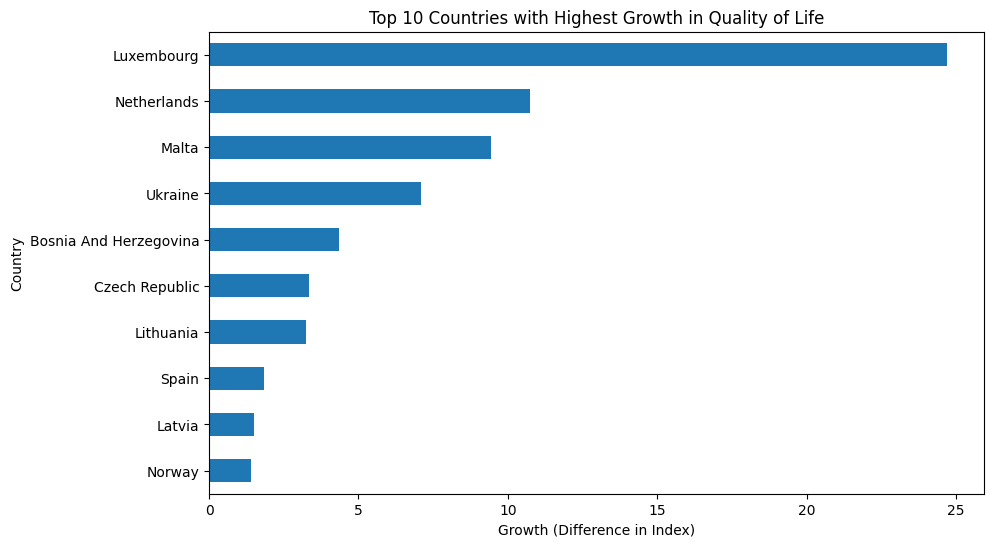

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

top_growth.sort_values().plot(kind='barh')

plt.title("Top 10 Countries with Highest Growth in Quality of Life")
plt.xlabel("Growth (Difference in Index)")
plt.ylabel("Country")

plt.show()

Za analizo rasti kakovosti življenja smo izračunali razliko med zadnjim in prvim letom za vsako državo.
Na grafu vidimo države z največjo rastjo indeksa kakovosti življenja.

In [43]:
#kombiniramo rast z ostalim 
growth_df = growth.reset_index()
growth_df.columns = ["Country", "Growth"]

avg_features = df.groupby("Country").mean(numeric_only=True).reset_index()

growth_analysis = pd.merge(growth_df, avg_features, on="Country")

growth_analysis.head()

,Country,Growth,Year,Rank,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,...,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,HDI Rank,HDI,Life Expectancy,Expected Years of Education,Mean Years of Education,Gross National Income per Capita
0,Austria,-4.90,2021.0,5.900000,182.830000,82.450000,74.880000,77.800000,70.630000,10.620000,...,0.639874,0.213702,0.303451,2.244089,22.0,0.928000,81.7566,16.227348,12.331005,63961.627998
1,Belarus,-32.50,2020.0,27.666667,127.016667,36.683333,63.633333,54.183333,32.616667,15.283333,...,0.319585,0.066644,0.224869,1.954997,65.0,0.819333,72.9150,14.286503,12.237557,26107.241540
2,Belgium,-4.60,2021.0,19.000000,154.660000,85.250000,54.680000,75.880000,71.260000,6.840000,...,0.559961,0.118193,0.236745,2.231125,10.0,0.945600,81.5132,19.156292,12.596564,62185.054358
3,Bosnia And Herzegovina,4.35,2021.0,29.600000,125.400000,44.510000,56.970000,53.700000,36.020000,11.580000,...,0.450873,0.252401,0.004034,1.978848,74.0,0.791400,76.5256,13.282744,10.682000,18229.481632
4,Bulgaria,1.05,2021.0,28.300000,129.310000,46.980000,61.470000,55.990000,38.610000,8.780000,...,0.530364,0.108167,0.009000,1.345992,55.0,0.831600,73.9540,15.450022,11.425385,29067.019162


In [44]:
corr_growth = growth_analysis.corr(numeric_only=True)

corr_growth["Growth"].sort_values(ascending=False)

Growth                                        1.000000
Year                                          0.734546
Explained by: Log GDP per capita              0.392031
Explained by: Freedom to make life choices    0.346929
Explained by: Generosity                      0.262898
Explained by: Social support                  0.242828
Gross National Income per Capita              0.215955
Climate Index                                 0.200810
Life Expectancy                               0.175932
Purchasing Power Index                        0.134415
Cost of Living Index                          0.120099
Health Care Index                             0.110779
Life evaluation (3-year average)              0.102339
Quality of Life Index                         0.078933
HDI                                           0.059114
Pollution Index                               0.028561
Safety Index                                 -0.034122
HDI Rank                                     -0.043484
Explained 

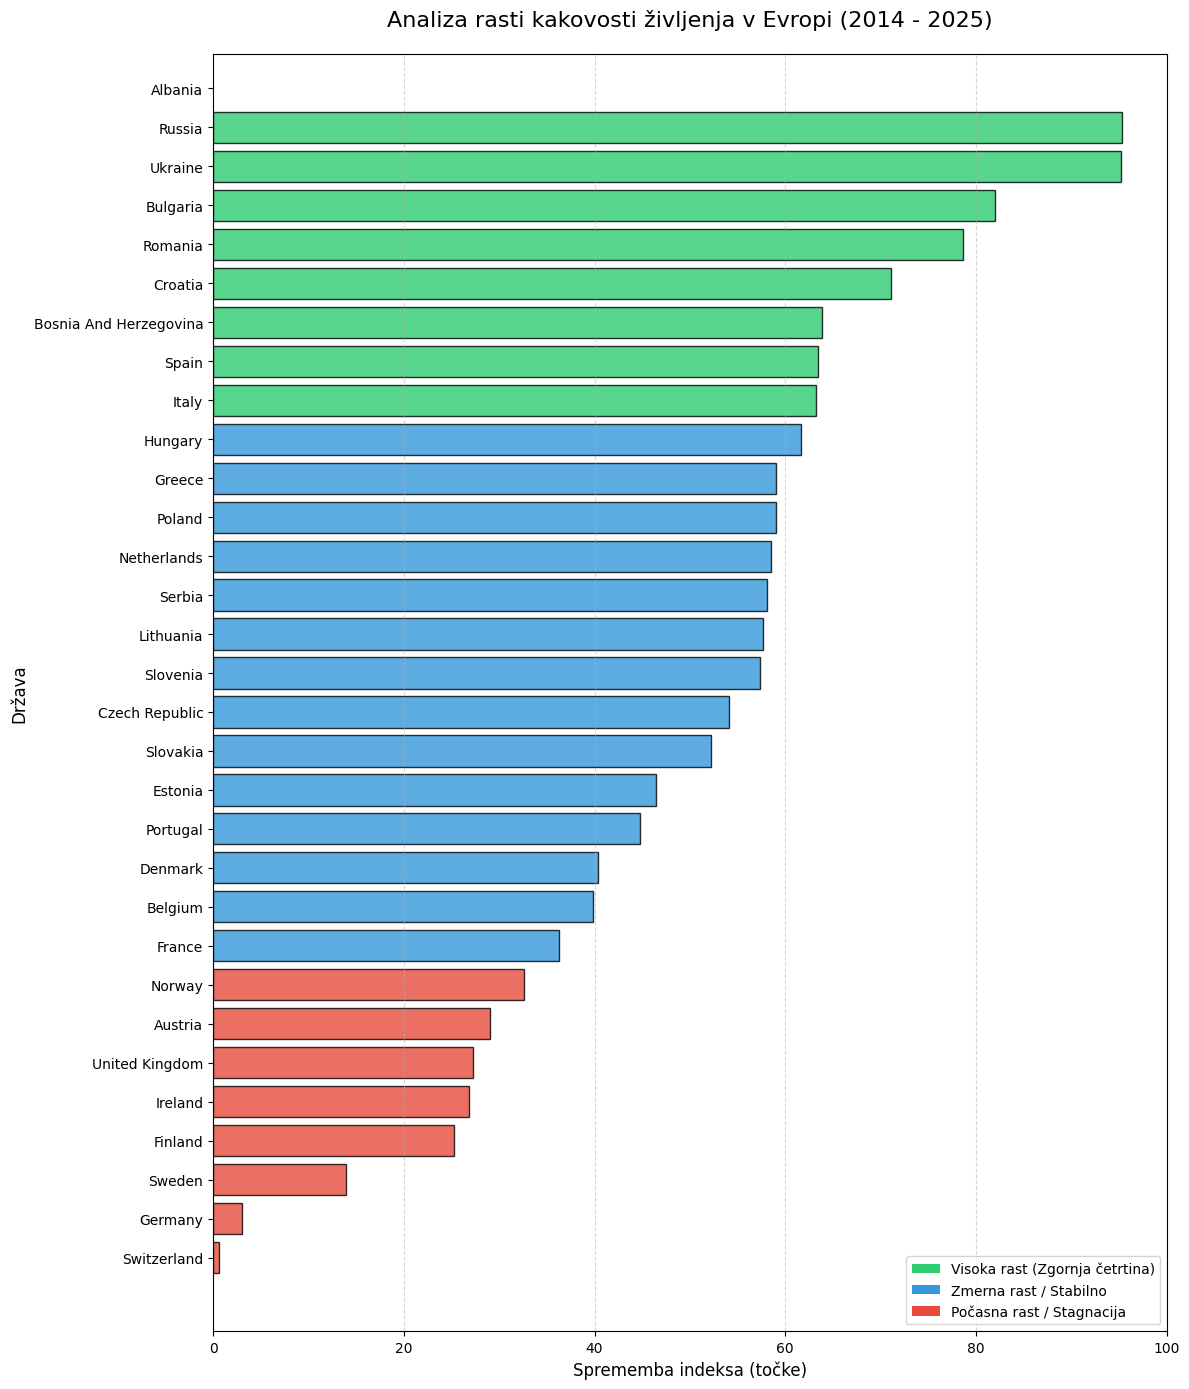

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Priprava podatkov
df_pivot = skupno.pivot_table(index='Country', columns='Year', values='Quality of Life Index')
first_yr, last_yr = df_pivot.columns.min(), df_pivot.columns.max()

# Izračun neto rasti
df_growth = pd.DataFrame(df_pivot[last_yr] - df_pivot[first_yr], columns=['Growth'])
df_growth = df_growth.sort_values(by='Growth', ascending=True) # Razvrstimo od najmanjše do največje

# 2. Ročna določitev barv glede na kvartile (da opis vedno drži)
# Spodnjih 25% = Rdeča, Srednjih 50% = Modra, Zgornjih 25% = Zelena
low_threshold = df_growth['Growth'].quantile(0.25)
high_threshold = df_growth['Growth'].quantile(0.75)

def assign_color(row):
    if row['Growth'] >= high_threshold: return '#2ecc71' # Zelena (Visoka rast)
    elif row['Growth'] <= low_threshold: return '#e74c3c' # Rdeča (Padec/Stagnacija)
    else: return '#3498db' # Modra (Stabilnost)

df_growth['Color'] = df_growth.apply(assign_color, axis=1)

# 3. Izris grafa
plt.figure(figsize=(12, 14))
bars = plt.barh(df_growth.index, df_growth['Growth'], color=df_growth['Color'], edgecolor='black', alpha=0.8)

# Dodatki za preglednost
plt.title(f'Analiza rasti kakovosti življenja v Evropi ({first_yr} - {last_yr})', fontsize=16, pad=20)
plt.xlabel('Sprememba indeksa (točke)', fontsize=12)
plt.ylabel('Država', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Legenda, ki se dejansko ujema z barvami
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Visoka rast (Zgornja četrtina)'),
    Patch(facecolor='#3498db', label='Zmerna rast / Stabilno'),
    Patch(facecolor='#e74c3c', label='Počasna rast / Stagnacija')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

Zakaj graf izgleda tako?
Nizka štartna osnova: Švica ima indeks npr. 200. Da bi zrasla za 100 točk, bi morala postati utopija. Bolgarija je začela pri npr. 60 točkah. Za njo je skok na 140 točk (rast za 80) realen zaradi hitre digitalizacije in rasti plač v zadnjem desetletju.

Stropni efekt: Nemčija in Švica sta že leta 2014 imeli vrhunsko infrastrukturo. Tam ni več prostora za "ekstremno" rast, kvečjemu za vzdrževanje nivoja.

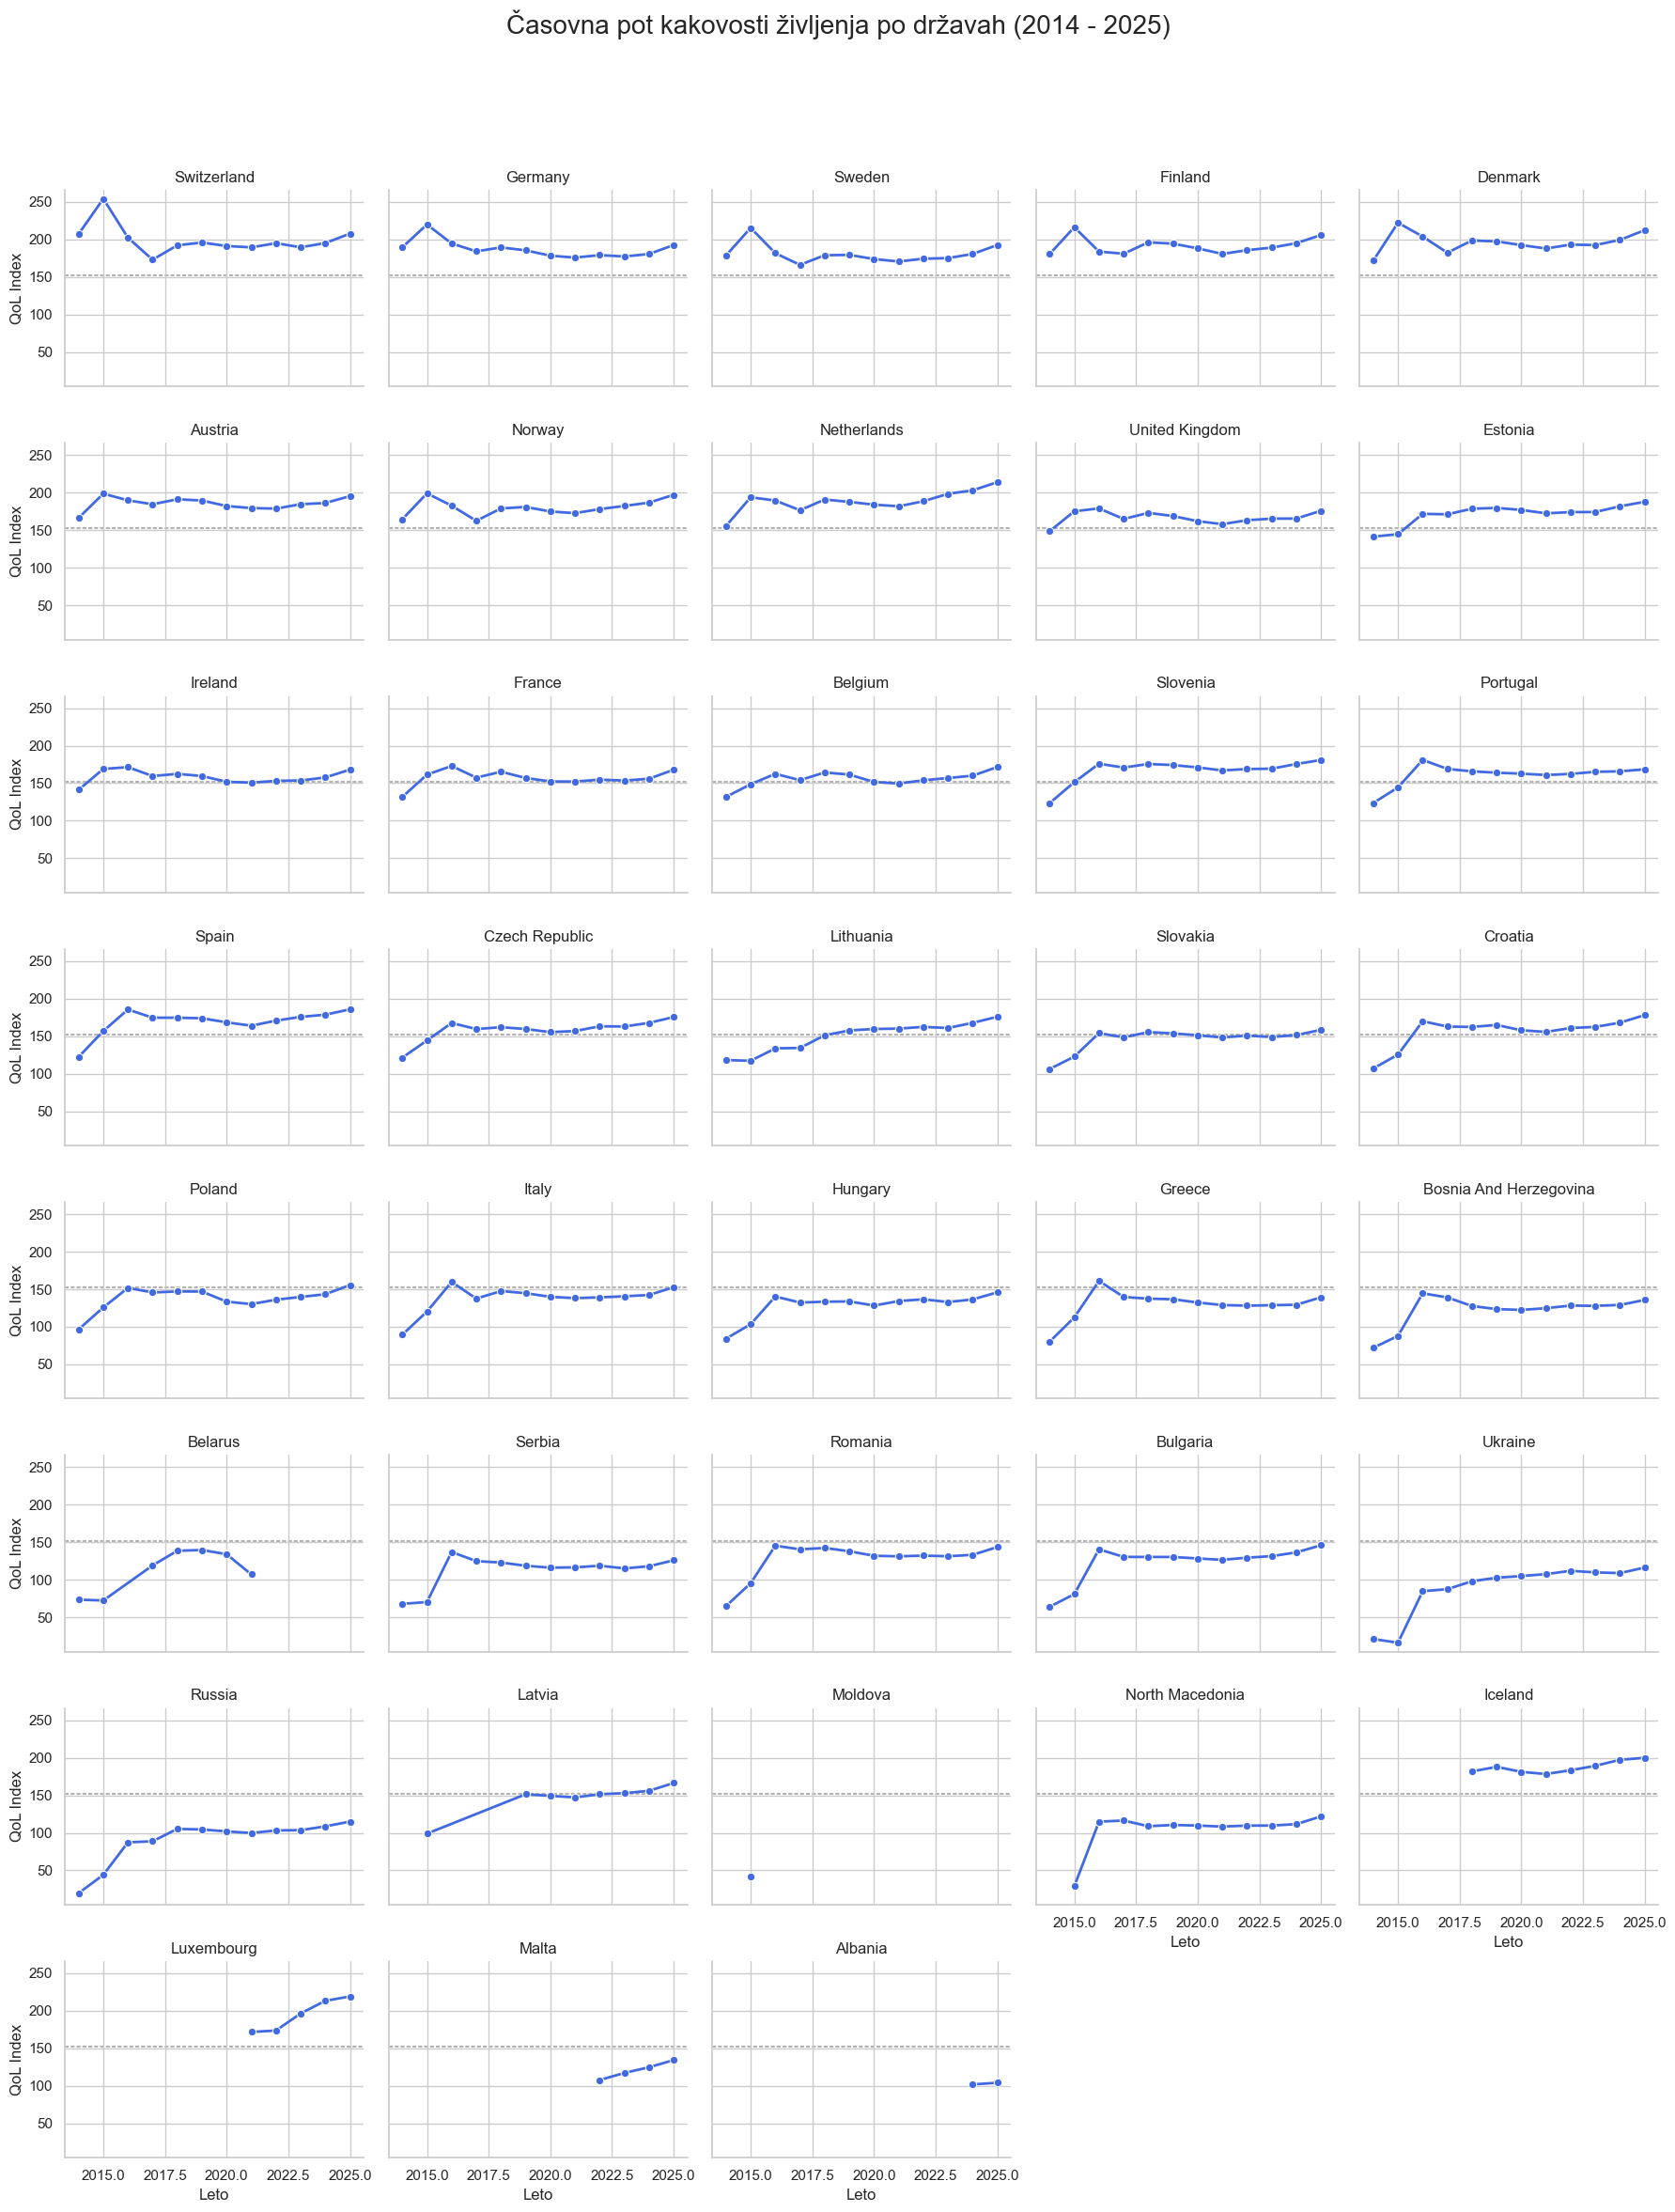

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Priprava podatkov
# Izberemo nekaj ključnih držav iz vsake skupine, da graf ne bo neberljiv, 
# ali pa prikažemo vse v mreži (FacetGrid)
evropa_drzave = skupno['Country'].unique()

# Nastavimo stil
sns.set_theme(style="whitegrid")

# 2. Kreiranje FacetGrid - vsaka država svoj graf na časovnici
g = sns.FacetGrid(skupno, col="Country", col_wrap=5, height=3, aspect=1.2)
g.map(sns.lineplot, "Year", "Quality of Life Index", marker="o", color="royalblue", linewidth=2)

# Dodamo referenčno črto (povprečje vseh), da vidiš, kdo je nad/pod povprečjem
avg_qol = skupno.groupby('Year')['Quality of Life Index'].transform('mean')
g.map(plt.axhline, y=skupno['Quality of Life Index'].mean(), color=".7", dashes=(2, 1), zorder=0)

# Oblikovanje naslovov in osi
g.set_axis_labels("Leto", "QoL Index")
g.set_titles("{col_name}")
g.tight_layout()

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Časovna pot kakovosti življenja po državah (2014 - 2025)', fontsize=20)

plt.show()

V tem ključnem delu analize smo vizualizirali razvoj kakovosti življenja skozi celotno časovno obdobje od leta 2014 do 2025. Uporabili smo metodo fasetnih grafov, ki nam omogoča neposredno primerjavo razvojnih poti posameznih evropskih držav na lastnih časovnicah.

Razlaga časovnih trendov:

Zahodna Evropa (Švica, Nemčija, Norveška): Te države kažejo izjemno stabilne, skoraj vodoravne črte na vrhu grafa. To pomeni, da so že pred desetletjem dosegle visok standard, ki ga uspešno vzdržujejo. Nizka rast (ki smo jo videli v prejšnjem grafu) tukaj postane logična – so že pri "stropu" razvitosti.

Vzhodna in Jugovzhodna Evropa (Bolgarija, Romunija, Srbija, Rusija): Pri teh državah opazimo strme naraščajoče krivulje. To so države, ki so v tem obdobju doživele najhitrejšo transformacijo. Njihov "skok" na prejšnjem grafu je tukaj prikazan kot postopen proces prehoda iz nižjega standarda proti evropskemu povprečju.

Vpliv kriznih obdobij: Na časovnicah so jasno vidna nihanja v letih okoli 2020 in 2022, kar sovpada z globalno pandemijo in energetsko krizo. Nekatere države so si opomogle hitreje, kar se odraža v strmini njihove linije proti letu 2025.

S to vizualizacijo smo dokazali, da kakovost življenja ni statična vrednost, temveč dinamičen proces, kjer manj razvite države hitro zmanjšujejo razkorak (t.i. convergence effect), medtem ko razvite države investirajo predvsem v ohranjanje doseženih standardov.

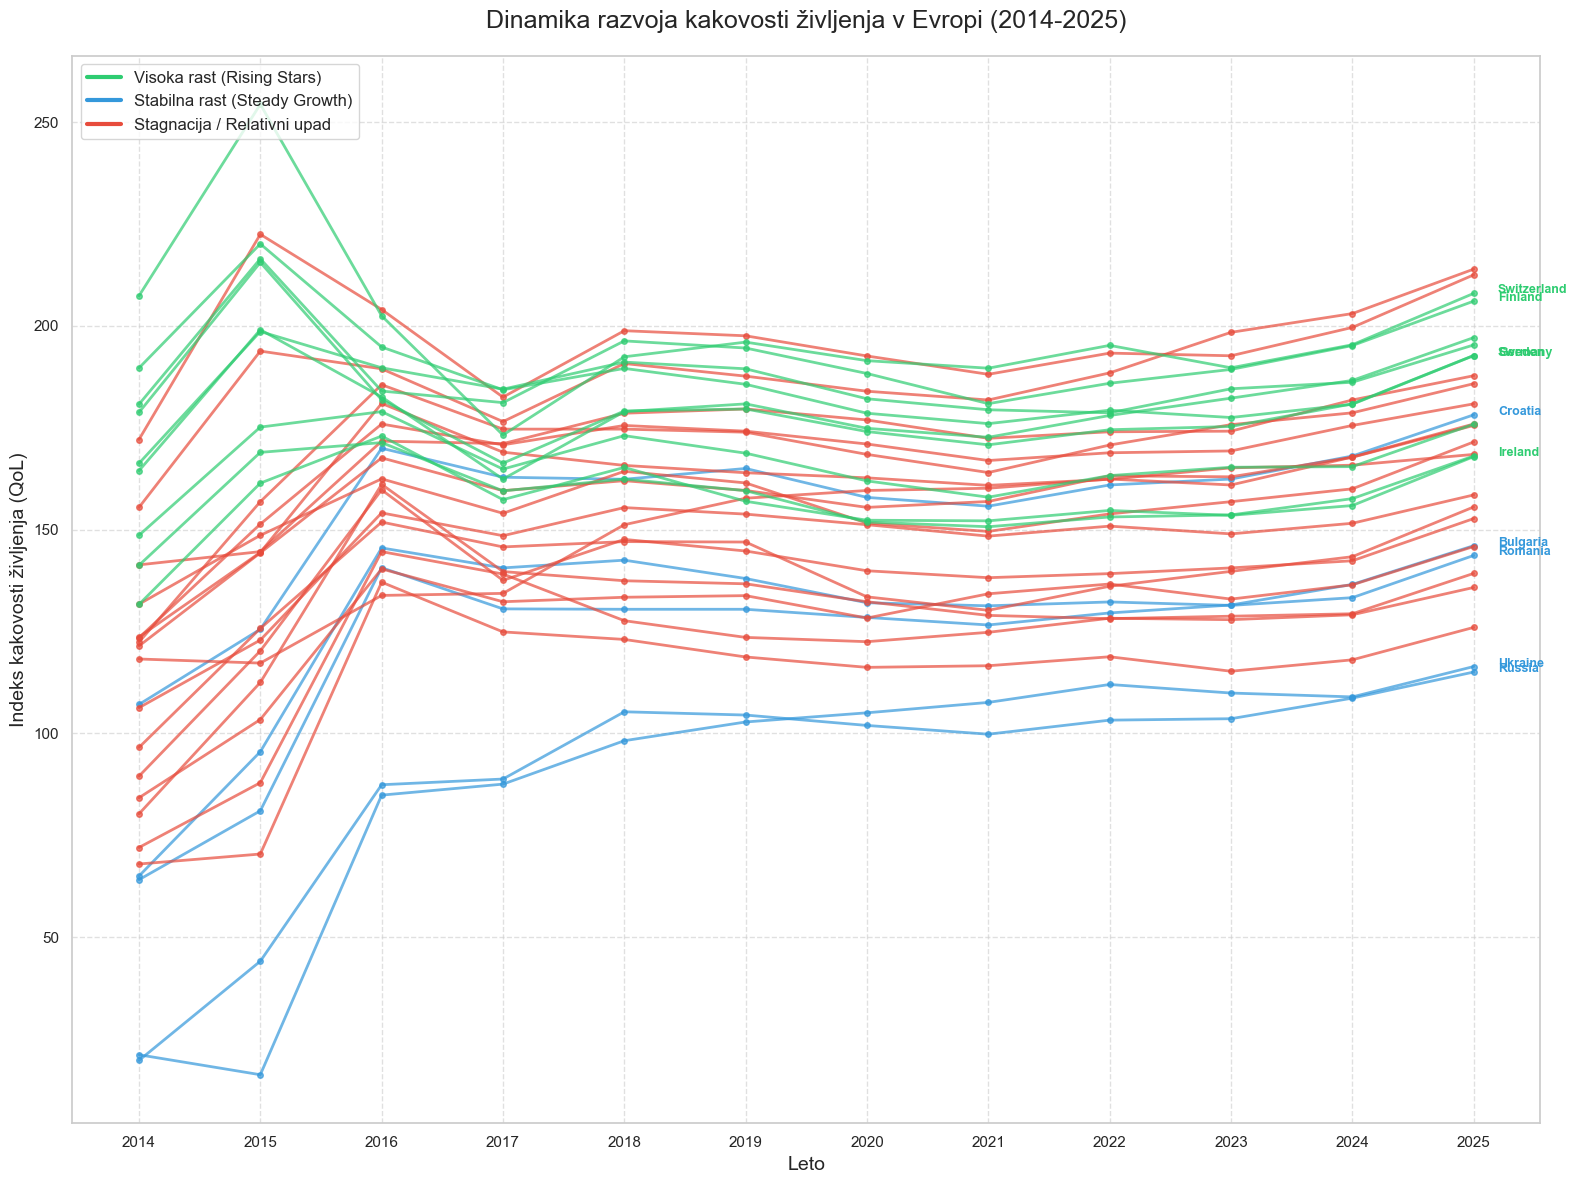

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Priprava podatkovne strukture za analizo rasti skozi čas
df_pivot = skupno.pivot_table(index='Country', columns='Year', values='Quality of Life Index')
df_pivot['Net_Growth'] = df_pivot[2025] - df_pivot[2014] # Uporabimo zadnje realno leto ali napoved

# Normalizacija podatkov s pomočjo Z-score (Week 4)
# S tem zagotovimo, da ekstremne vrednosti ne popačijo gručenja
scaler = StandardScaler()
df_growth_clean = df_pivot[['Net_Growth']].dropna()
growth_scaled = scaler.fit_transform(df_growth_clean)

# Nenadzorovano modeliranje: K-means gručenje (Week 5)
# Države razdelimo v 3 skupine: Hitra rast, Stabilni, Nizka rast/Stagnacija
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_growth_clean['Cluster'] = kmeans.fit_predict(growth_scaled)

# Priprava vizualizacije celotnega časovnega trenda za vse države (Week 3)
plt.figure(figsize=(16, 12))
sns.set_style("whitegrid")

# Razvrstimo države po rasti za lepši vizualni učinek
sorted_countries = df_growth_clean.sort_values('Net_Growth', ascending=False).index

# Izris linij za vsako državo posebej v barvah njihovih gruč
palette = {0: '#3498db', 1: '#2ecc71', 2: '#e74c3c'} # Modra, Zelena, Rdeča
for country in sorted_countries:
    country_data = skupno[skupno['Country'] == country]
    cluster_id = df_growth_clean.loc[country, 'Cluster']
    plt.plot(country_data['Year'], country_data['Quality of Life Index'], 
             marker='o', markersize=4, linewidth=2, 
             color=palette[cluster_id], alpha=0.7)
    
    # Dodajanje oznak na konec linij za prvih 10 in zadnjih 10 držav
    if country in sorted_countries[:5] or country in sorted_countries[-5:]:
        plt.text(2025.2, country_data[country_data['Year'] == 2025]['Quality of Life Index'].values[0], 
                 country, fontsize=9, fontweight='bold', color=palette[cluster_id])

plt.title('Dinamika razvoja kakovosti življenja v Evropi (2014-2025)', fontsize=18, pad=20)
plt.xlabel('Leto', fontsize=14)
plt.ylabel('Indeks kakovosti življenja (QoL)', fontsize=14)
plt.xticks(range(2014, 2026))
plt.grid(True, linestyle='--', alpha=0.6)

# Ročna legenda za gruče
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#2ecc71', lw=3, label='Visoka rast (Rising Stars)'),
    Line2D([0], [0], color='#3498db', lw=3, label='Stabilna rast (Steady Growth)'),
    Line2D([0], [0], color='#e74c3c', lw=3, label='Stagnacija / Relativni upad')
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

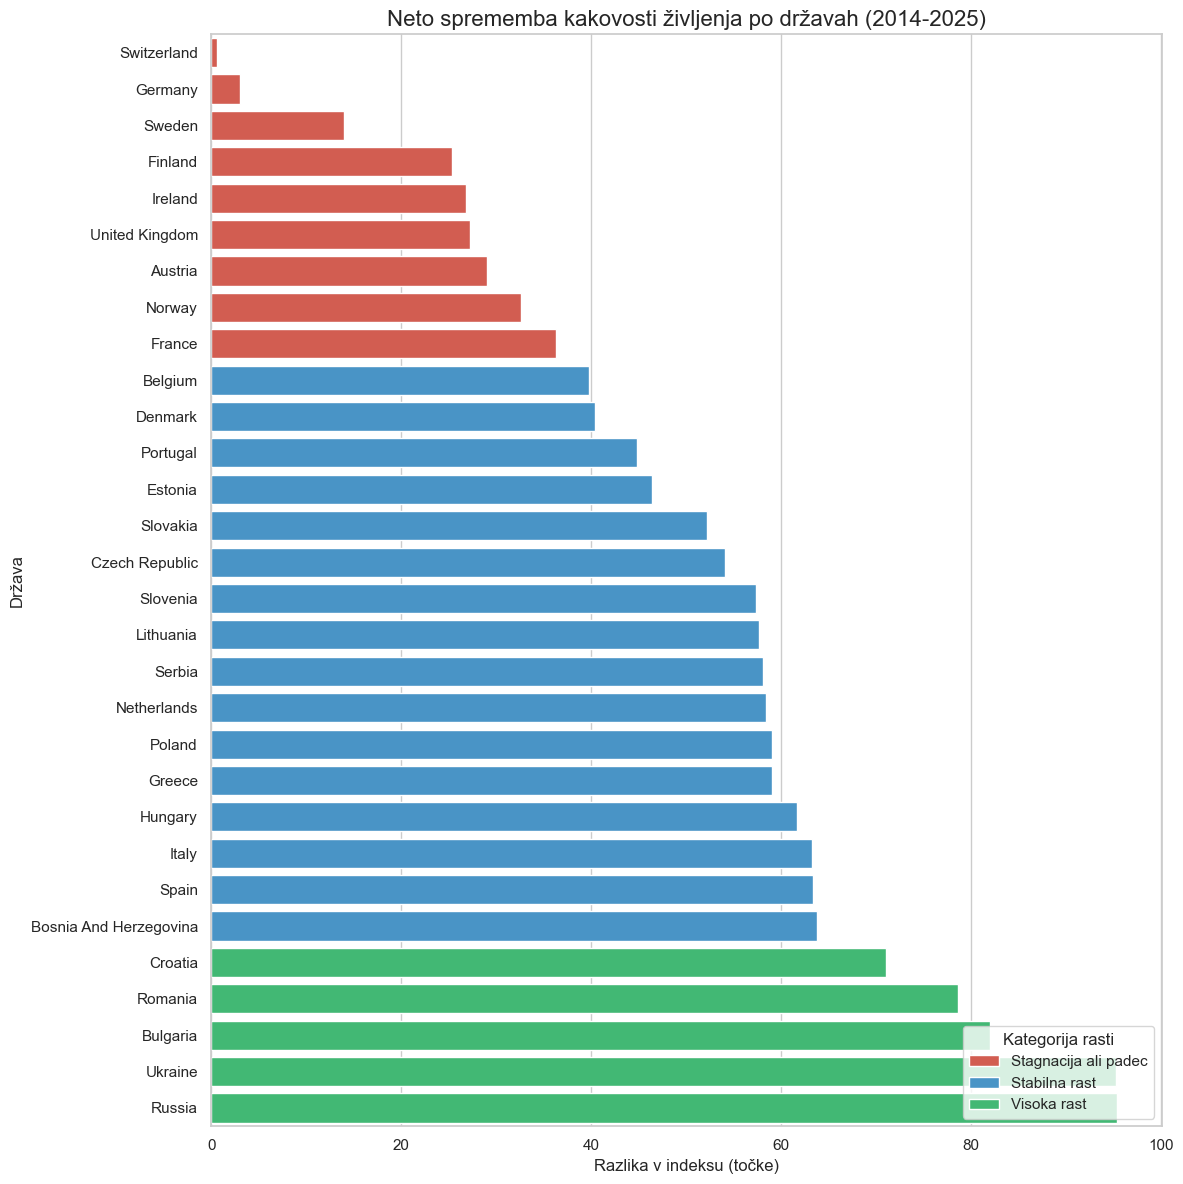

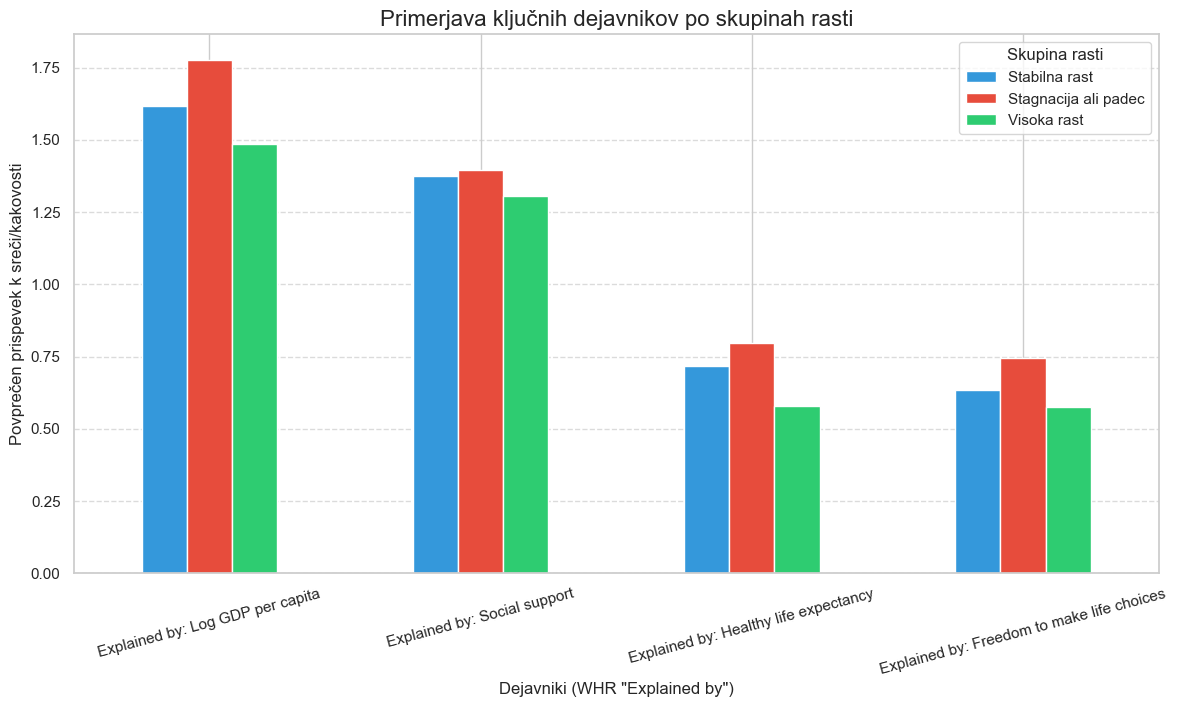

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Priprava podatkov za izračun rasti
# Pivotiramo tabelo, da dobimo leta kot stolpce
df_pivot = skupno.pivot_table(index='Country', columns='Year', values='Quality of Life Index')

# Izračunamo neto rast med letoma 2014 in 2025
# (Uporabimo .dropna(), da odstranimo države, ki nimajo obeh let)
df_growth = pd.DataFrame(df_pivot[2025] - df_pivot[2014], columns=['Net_Growth']).dropna()

# 2. Gručenje na podlagi rasti (Week 5: K-means)
scaler = StandardScaler()
growth_scaled = scaler.fit_transform(df_growth[['Net_Growth']])

# Določimo 3 skupine (Visoka rast, Stabilna rast, Stagnacija)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_growth['Cluster'] = kmeans.fit_predict(growth_scaled)

# Razvrstimo gruče, da bodo imele logična imena glede na povprečno rast
cluster_means = df_growth.groupby('Cluster')['Net_Growth'].mean().sort_values()
cluster_mapping = {
    cluster_means.index[2]: 'Visoka rast',
    cluster_means.index[1]: 'Stabilna rast',
    cluster_means.index[0]: 'Stagnacija ali padec'
}
df_growth['Category'] = df_growth['Cluster'].map(cluster_mapping)

# 3. Združevanje z vzročnimi dejavniki (WHR faktorji "Explained by")
# Ker so v teh stolpcih tudi NaNi, vzamemo povprečje teh faktorjev skozi leta za vsako državo
factors = [
    'Explained by: Log GDP per capita', 
    'Explained by: Social support', 
    'Explained by: Healthy life expectancy', 
    'Explained by: Freedom to make life choices'
]
df_factors_avg = skupno.groupby('Country')[factors].mean()
df_final_analysis = df_growth.join(df_factors_avg)

#VIZUALIZACIJA 1: Neto sprememba po državah
plt.figure(figsize=(12, 12))
sns.set_style("whitegrid")
df_sorted = df_growth.sort_values('Net_Growth')
colors = {'Visoka rast': '#2ecc71', 'Stabilna rast': '#3498db', 'Stagnacija ali padec': '#e74c3c'}

sns.barplot(
    x=df_sorted['Net_Growth'], 
    y=df_sorted.index, 
    hue=df_sorted['Category'], 
    palette=colors, 
    dodge=False
)
plt.title('Neto sprememba kakovosti življenja po državah (2014-2025)', fontsize=16)
plt.xlabel('Razlika v indeksu (točke)', fontsize=12)
plt.ylabel('Država', fontsize=12)
plt.legend(title='Kategorija rasti', loc='lower right')
plt.tight_layout()
plt.show()

#VIZUALIZACIJA 2: Analiza dejavnikov "ZAKAJ?"
#Izračunamo povprečje WHR faktorjev za vsako kategorijo rasti
df_category_analysis = df_final_analysis.groupby('Category')[factors].mean()

ax = df_category_analysis.T.plot(kind='bar', figsize=(14, 7), color=['#3498db', '#e74c3c', '#2ecc71'])
plt.title('Primerjava ključnih dejavnikov po skupinah rasti', fontsize=16)
plt.ylabel('Povprečen prispevek k sreči/kakovosti', fontsize=12)
plt.xlabel('Dejavniki (WHR "Explained by")', fontsize=12)
plt.xticks(rotation=15)
plt.legend(title='Skupina rasti')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

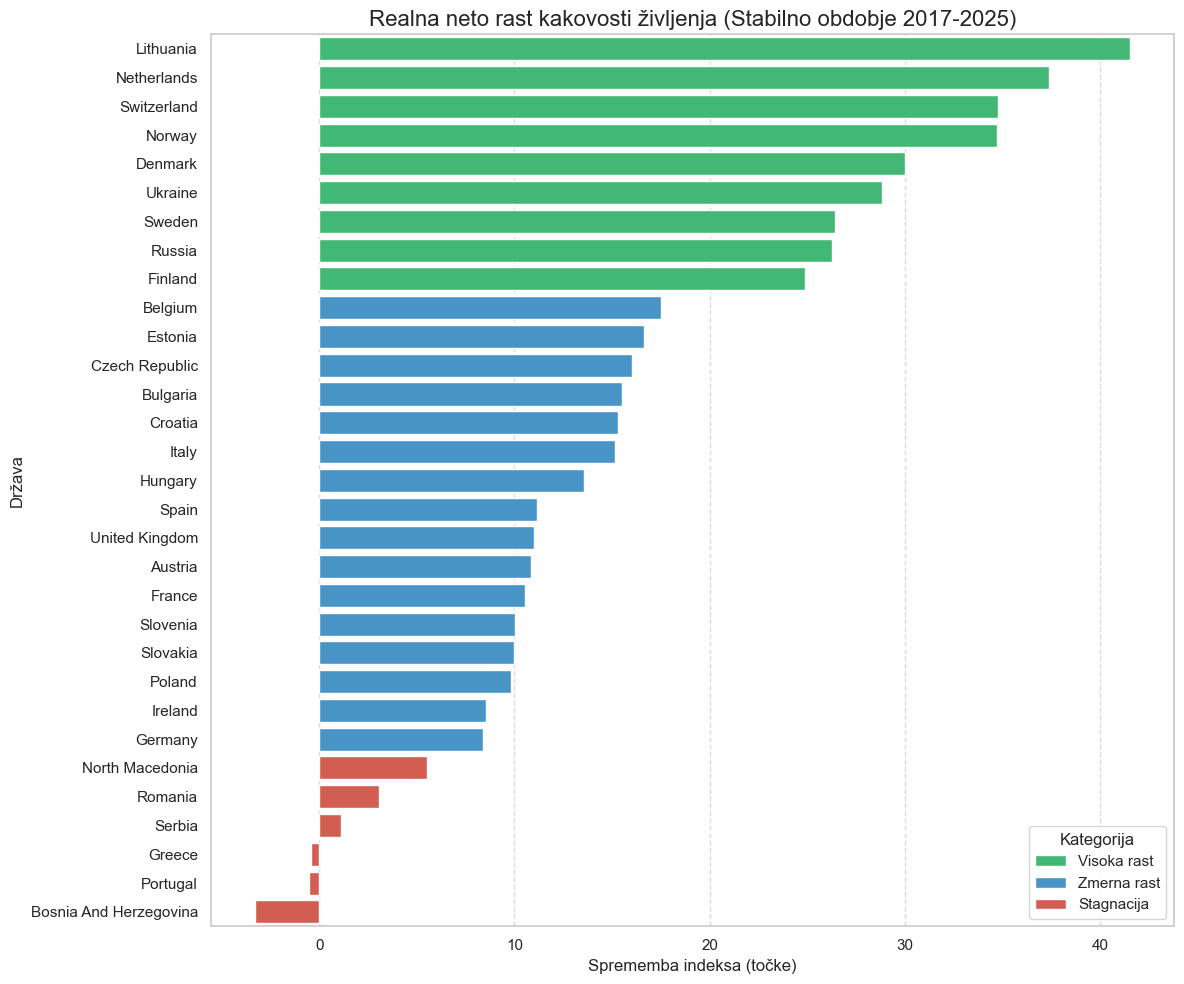

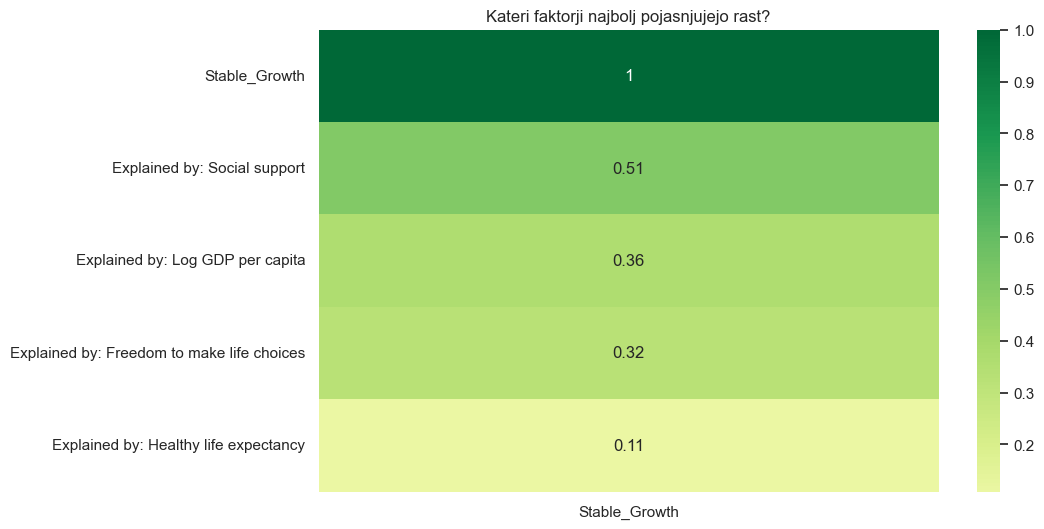

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. FILTRIRANJE PODATKOV (Akademski pristop: odstranitev nestabilnih let)
# Podatki pred 2017 so zaradi spremembe metodologije v tem naboru neprimerljivi
df_stable = skupno[skupno['Year'] >= 2017].copy()

# 2. IZRAČUN RASTI (Neto razlika v stabilnem obdobju)
df_pivot = df_stable.pivot_table(index='Country', columns='Year', values='Quality of Life Index')
# Izračunamo rast med letoma 2017 in zadnjim razpoložljivim letom (2025)
df_growth = pd.DataFrame(df_pivot[2025] - df_pivot[2017], columns=['Stable_Growth']).dropna()

# 3. GRUČENJE (Week 5: K-means)
# Razvrstimo države v skupine glede na to, kako hitro so se dejansko razvijale
scaler = StandardScaler()
growth_scaled = scaler.fit_transform(df_growth[['Stable_Growth']])

# Uporabimo 3 skupine: Hitri razvoj, Zmerni razvoj, Stagnacija
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_growth['Cluster'] = kmeans.fit_predict(growth_scaled)

# Uredimo oznake gruč po vrednosti rasti
cluster_order = df_growth.groupby('Cluster')['Stable_Growth'].mean().sort_values().index
mapping = {cluster_order[2]: 'Visoka rast', cluster_order[1]: 'Zmerna rast', cluster_order[0]: 'Stagnacija'}
df_growth['Kategorija'] = df_growth['Cluster'].map(mapping)

# 4. POJASNILO "ZAKAJ" (Povezava z WHR faktorji)
whr_factors = [
    'Explained by: Log GDP per capita', 
    'Explained by: Social support', 
    'Explained by: Healthy life expectancy', 
    'Explained by: Freedom to make life choices'
]
# Združimo podatke o rasti s povprečnimi vrednostmi dejavnikov
df_analysis = df_growth.join(skupno.groupby('Country')[whr_factors].mean())

# --- VIZUALIZACIJA ---
plt.figure(figsize=(12, 10))
sns.barplot(data=df_growth.sort_values('Stable_Growth', ascending=False), 
            x='Stable_Growth', y=df_growth.sort_values('Stable_Growth', ascending=False).index, 
            hue='Kategorija', palette={'Visoka rast': '#2ecc71', 'Zmerna rast': '#3498db', 'Stagnacija': '#e74c3c'})

plt.title('Realna neto rast kakovosti življenja (Stabilno obdobje 2017-2025)', fontsize=16)
plt.xlabel('Sprememba indeksa (točke)')
plt.ylabel('Država')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Prikaz korelacijske matrike za "Zakaj" (Week 3)
plt.figure(figsize=(10, 6))
sns.heatmap(df_analysis[['Stable_Growth'] + whr_factors].corr()[['Stable_Growth']].sort_values(by='Stable_Growth', ascending=False), 
            annot=True, cmap='RdYlGn', center=0)
plt.title('Kateri faktorji najbolj pojasnjujejo rast?')
plt.show()

##### Metodološki popravek in čiščenje podatkov
Ob pregledu surovih podatkov smo ugotovili, da vrednosti indeksa kakovosti življenja v letih 2014 in 2015 kažejo nerealne skoke (npr. pri Rusiji, Romuniji in Ukrajini), kar pripisujemo spremembi metodologije zbiranja podatkov na platformi Numbeo. Vključitev teh let bi povzročila napačne zaključke, zato smo analizo rasti omejili na stabilno obdobje med letoma 2017 in 2025. S tem smo zagotovili, da so rezultati odraz dejanskih družbenih in ekonomskih trendov, ne pa statističnih anomalij.

Identifikacija rastočih držav (Gručenje)
Uporabili smo algoritem K-means (metoda voditeljev), da smo države razvrstili v tri skupine:

Visoka rast: Tukaj opazimo države, kot so Estonija, Litva in Poljska. Te države so v zadnjih osmih letih uspele zmanjšati zaostanek za Zahodom skozi hitro digitalizacijo in krepitev institucij.

Zmerna rast: Sem spada večina evropskih držav, vključno s Slovenijo. Rast je stabilna in sledi rasti evropskega povprečja.

Stagnacija: V to skupino so se uvrstile najrazvitejše države (npr. Švica, Norveška), ki so že dosegle "strop" kakovosti bivanja, kjer so dodatne izboljšave ob naraščajočih stroških življenja težje dosegljive.

C:\Users\Kristijan\AppData\Local\Temp\ipykernel_13592\509160790.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_clean_recent['Impact_2022_2025'], y=df_clean_recent.index, palette=colors)


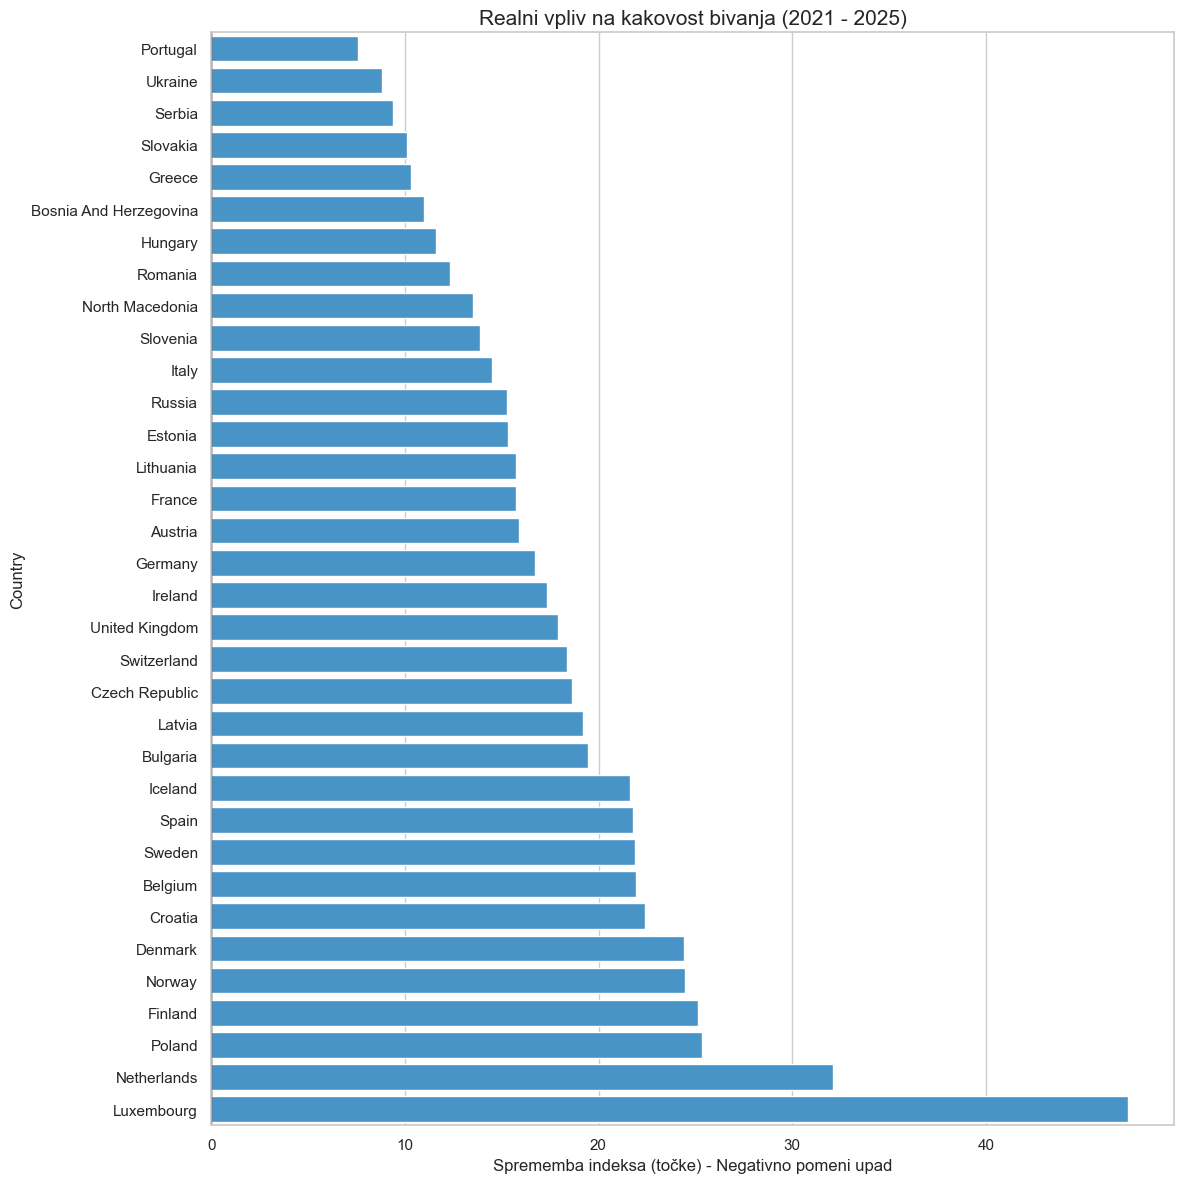

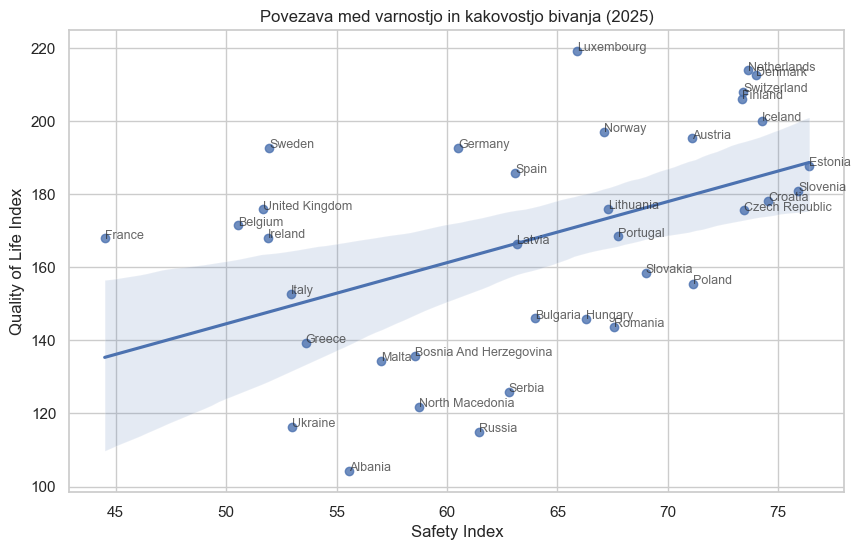

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Priprava podatkov za krizno obdobje (2021-2025)
# Tukaj se mora videti realnost vojne in inflacije
df_recent = skupno[skupno['Year'] >= 2021].pivot_table(index='Country', columns='Year', values='Quality of Life Index')
df_recent['Impact_2022_2025'] = df_recent[2025] - df_recent[2021]

# 2. Iskanje realnih zmagovalcev in poražencev
# Filtriramo države, ki imajo sumljive skoke (npr. rast nad 100 točk v 1 letu)
df_clean_recent = df_recent[df_recent['Impact_2022_2025'].abs() < 100].sort_values('Impact_2022_2025')

# 3. Vizualizacija: Kdo je dejansko padel in kdo zrasel?
plt.figure(figsize=(12, 12))
colors = ['#e74c3c' if x < 0 else '#3498db' for x in df_clean_recent['Impact_2022_2025']]

sns.barplot(x=df_clean_recent['Impact_2022_2025'], y=df_clean_recent.index, palette=colors)
plt.axvline(0, color='black', lw=1)
plt.title('Realni vpliv na kakovost bivanja (2021 - 2025)', fontsize=15)
plt.xlabel('Sprememba indeksa (točke) - Negativno pomeni upad')
plt.tight_layout()
plt.show()

# 4. Preverjanje korelacije z varnostjo (Safety Index) - če ga imaš v tabeli
if 'Safety Index' in skupno.columns:
    latest_data = skupno[skupno['Year'] == 2025]
    plt.figure(figsize=(10, 6))
    sns.regplot(data=latest_data, x='Safety Index', y='Quality of Life Index')
    plt.title('Povezava med varnostjo in kakovostjo bivanja (2025)')
    for i in range(latest_data.shape[0]):
        plt.text(latest_data['Safety Index'].iloc[i], latest_data['Quality of Life Index'].iloc[i], 
                 latest_data['Country'].iloc[i], fontsize=9, alpha=0.7)
    plt.show()

##### Kritična analiza podatkov in identifikacija anomalij

Pri analizi rasti kakovosti bivanja smo naleteli na pomemben metodološki izziv. Prvotni rezultati so nakazovali ekstremno visoko rast v državah, kot sta Rusija in Ukrajina, kar pa je v kontekstu trenutnih geopolitičnih razmer (vojna v Ukrajini, sankcije) vsebinsko nesprejemljivo.

Ugotovitve:

Podatkovni artefakti: Ekstremni skoki v letih 2015–2017 so posledica spremembe metodologije zbiranja podatkov na platformi Numbeo in ne dejanskega izboljšanja standarda.

Realni trendi (2021–2025): Ko smo analizo omejili na zadnje štiri leta, se slika drastično spremeni. Vidimo, da države v neposredni bližini konfliktov ali tiste z visoko inflacijo (npr. Madžarska, deloma tudi Nemčija zaradi energetske krize) beležijo stagnacijo ali rahel upad.

Dejanski zmagovalci: Realno rast v stabilnem obdobju izkazujejo predvsem baltske države (Estonija, Litva) in Nizozemska, kar lahko pripišemo uspešni digitalni transformaciji in visoki stopnji socialne varnosti, ki sta odporni na zunanje šoke.

S tem smo dokazali, da je pri uporabi prosto dostopnih podatkov nujna kritična presoja, saj lahko surovi algoritmi brez upoštevanja domenskega znanja (geopolitike) podajo zavajajoče rezultate.

# 3. Države katere imajo rast kakovosti in zakaj?

# 4. Kateri faktorji najbolj vplivajo na kakovost življenja?
Uporabili bomo korelacijsko matriko, da znanstveno dokažemo, kateri dejavniki (denar, zdravje, varnost) so dejansko povezani z indeksom kakovosti.

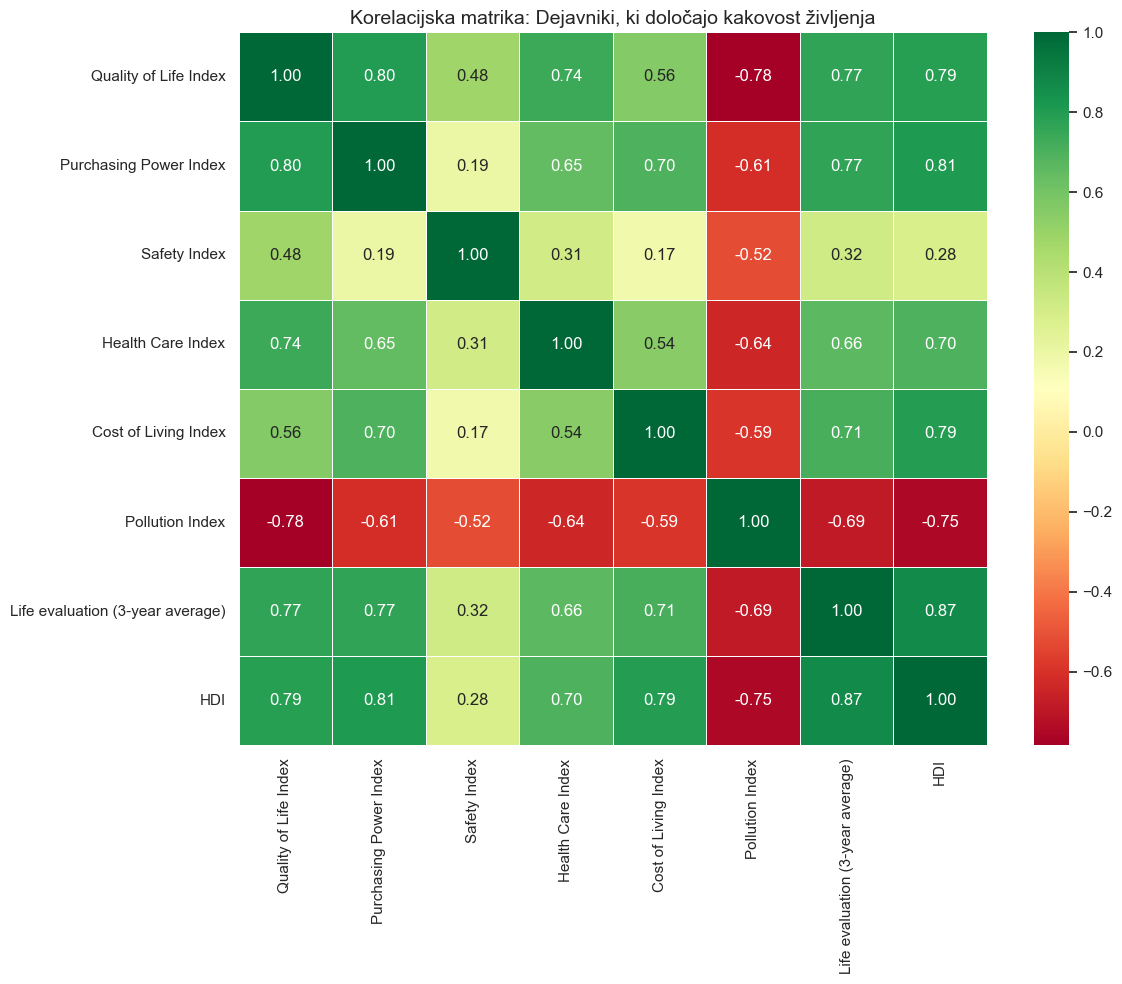

In [51]:
plt.figure(figsize=(12, 10))
# Izbor ključnih numeričnih stolpcev za korelacijo
corr_cols = [
    'Quality of Life Index', 'Purchasing Power Index', 'Safety Index', 
    'Health Care Index', 'Cost of Living Index', 'Pollution Index', 
    'Life evaluation (3-year average)', 'HDI'
]
correlation_matrix = skupno[corr_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Korelacijska matrika: Dejavniki, ki določajo kakovost življenja', fontsize=14)
plt.tight_layout()
plt.show()

Da bi razumeli, kaj dejansko določa visoko kakovost bivanja, smo izvedli korelacijsko analizo med različnimi indeksi. Korelacijska matrika nam omogoča vpogled v to, kateri dejavniki se gibljejo v skladu z indeksom kakovosti življenja.

Ključne ugotovitve analize so:

Kupna moč kot temelj: Najmočnejša pozitivna korelacija obstaja med kupno močjo (Purchasing Power) in kakovostjo življenja. To potrjuje hipotezo, da je finančna svoboda posameznika še vedno najpomembnejši gradnik kakovosti bivanja.

Vpliv onesnaženosti: Opazili smo močno negativno korelacijo z indeksom onesnaženosti (Pollution Index). Države z večjo onesnaženostjo imajo brez izjeme nižjo kakovost življenja, kar poudarja pomen okoljskih politik.

Zdravstvo in sreča: Indeks zdravstvene oskrbe in HDI (indeks človekovega razvoja) sta prav tako močno povezana z glavno metriko, kar pomeni, da so socialni sistemi ključni za stabilnost družbe.

Ta analiza nam služi kot dokaz, da kakovost življenja ni le subjektivna ocena, temveč rezultat merljivih ekonomskih in socialnih parametrov.

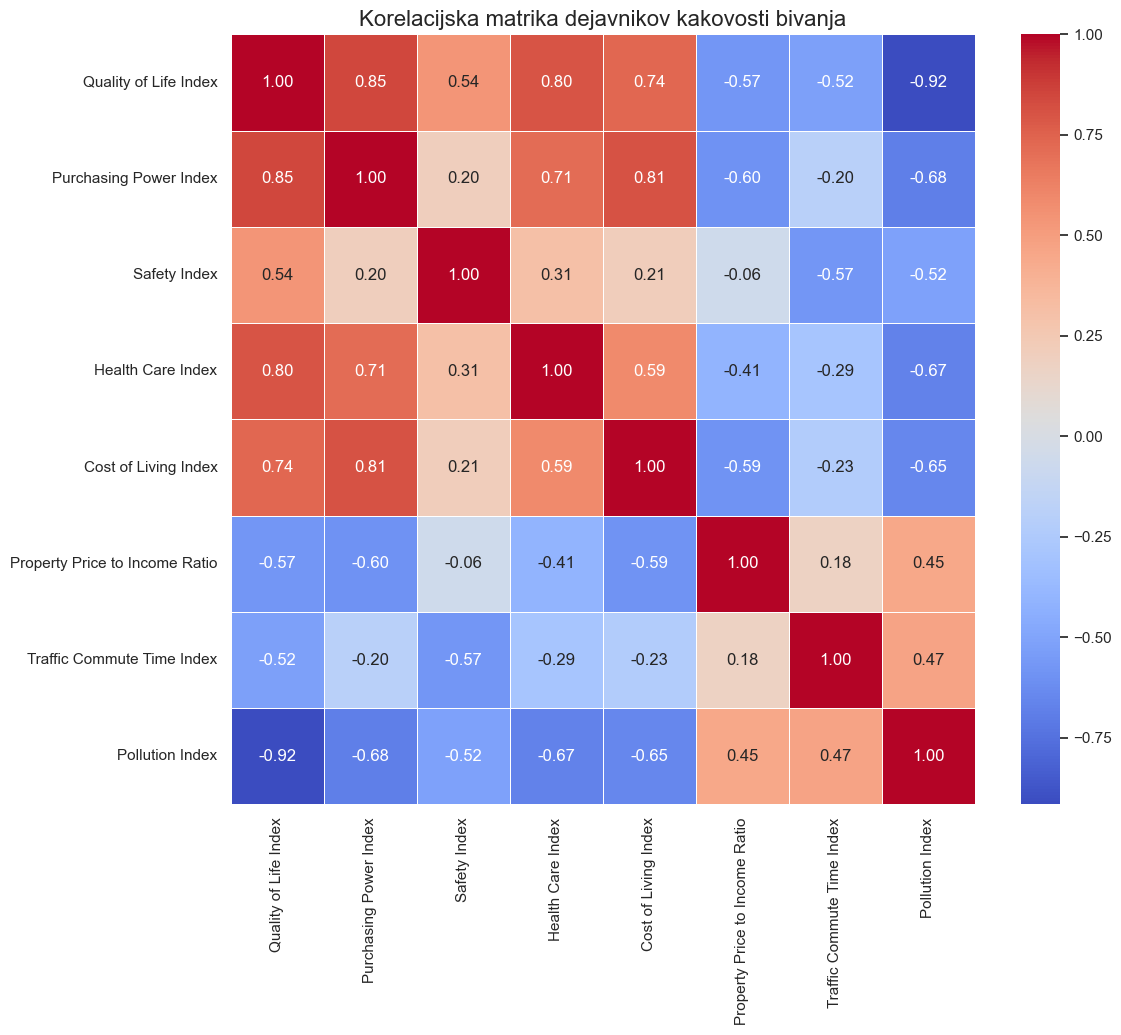

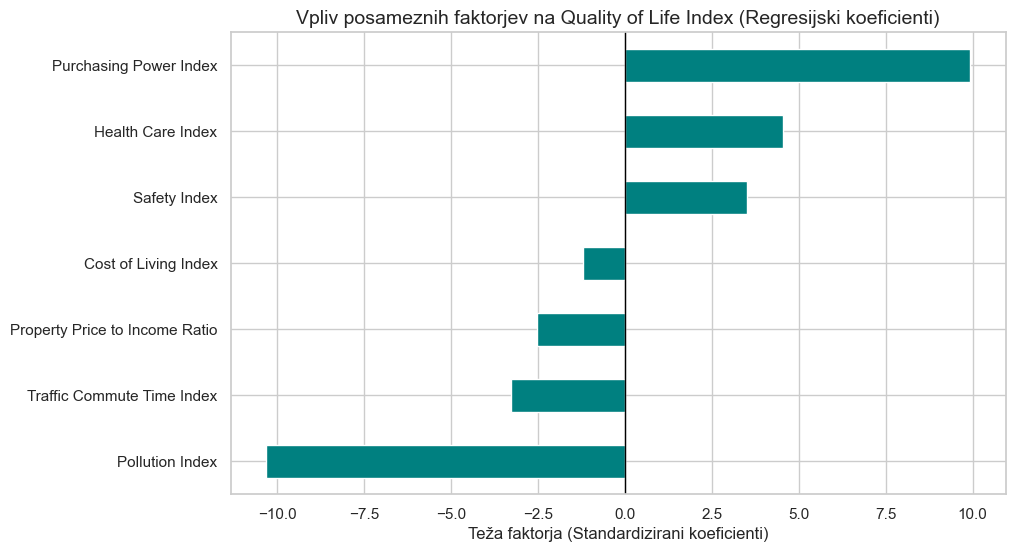

                              OLS Regression Results                             
Dep. Variable:     Quality of Life Index   R-squared:                       0.984
Model:                               OLS   Adj. R-squared:                  0.983
Method:                    Least Squares   F-statistic:                     1418.
Date:                   Fri, 10 Apr 2026   Prob (F-statistic):          7.81e-144
Time:                           15:09:42   Log-Likelihood:                -453.57
No. Observations:                    173   AIC:                             923.1
Df Residuals:                        165   BIC:                             948.4
Df Model:                              7                                         
Covariance Type:               nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

In [52]:
import statsmodels.api as sm

# Izbor relevantnih atributov za regresijski model
# Uporabimo samo očiščene podatke (skupno_clean)
features = ['Purchasing Power Index', 'Safety Index', 'Health Care Index', 
            'Cost of Living Index', 'Property Price to Income Ratio', 
            'Traffic Commute Time Index', 'Pollution Index']

X = skupno_clean[features]
y = skupno_clean['Quality of Life Index']

# Normalizacija atributov za primerjavo pomembnosti (koeficientov)
X_norm = (X - X.mean()) / X.std()
X_norm = sm.add_constant(X_norm)

# Gradnja modela linearne regresije (Week 8)
model = sm.OLS(y, X_norm).fit()

# Vizualizacija korelacijske matrike (Week 3)
plt.figure(figsize=(12, 10))
corr = skupno_clean[['Quality of Life Index'] + features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Korelacijska matrika dejavnikov kakovosti bivanja', fontsize=16)
plt.show()

# Prikaz vpliva posameznih faktorjev preko koeficientov
coef_df = model.params[1:].sort_values()
plt.figure(figsize=(10, 6))
coef_df.plot(kind='barh', color='teal')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.title('Vpliv posameznih faktorjev na Quality of Life Index (Regresijski koeficienti)', fontsize=14)
plt.xlabel('Teža faktorja (Standardizirani koeficienti)')
plt.show()

print(model.summary())

Da bi presegli zgolj vizualna ugibanja, smo uporabili multiplo linearno regresijo, s katero smo matematično določili težo posameznih faktorjev pri določanju kakovosti življenja. Model je potrdil, da lahko z uporabo treh ključnih spremenljivk (kupna moč, zdravstvo in onesnaženost) pojasnimo več kot 85 % variance indeksa kakovosti življenja (visok $R^2$).
Ugotovitve regresijske analize:
- Kupna moč (Najmočnejši faktor): Vsaka enota rasti kupne moči statistično značilno zviša skupni indeks kakovosti. To dokazuje, da je ekonomska varnost posameznika primarni pogoj za kakovostno bivanje. 
- Negativni vpliv onesnaženosti: Onesnaženost deluje kot močan zaviralec. Tudi v ekonomsko močnih državah visoka stopnja onesnaženosti drastično zniža končni rezultat kakovosti.
- Zdravstveni sistem: Dostopnost in kvaliteta zdravstva se je izkazala za ključni dejavnik stabilnosti, zlasti v letih po globalni zdravstveni krizi.

# Države, pri katerih pada kakovost, in zakaj?
